# Breast Cancer Classification Using Machine Learning and SHAP Explainability

## Project Overview
This project applies machine learning to classify breast tumors as malignant or benign using the Wisconsin Breast Cancer Dataset. 

The workflow includes:
- exploratory data analysis
- feature correlation analysis
- logistic regression modeling
- model evaluation
- SHAP-based explainability

The goal is not only to achieve strong predictive performance, but also to understand which biological features most influence the model’s decisions.

## 1. Data Loading and Initial Exploration

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="diagnosis")

df = pd.concat([X, y], axis=1)

print("Dataset shape:", df.shape)
print("\nTarget labels:", data.target_names)
df.head()

Dataset shape: (569, 31)

Target labels: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [2]:
df["diagnosis_label"] = df["diagnosis"].map({0: "malignant", 1: "benign"})
df[["diagnosis", "diagnosis_label"]].head()

,diagnosis,diagnosis_label
0,0,malignant
1,0,malignant
2,0,malignant
3,0,malignant
4,0,malignant


In [3]:
print(df.info())
print("\nMissing values:", df.isnull().sum().sum())
print("\nClass distribution:\n", df["diagnosis_label"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

### Observations

- The dataset contains 569 samples and 30 numerical features.
- There are no missing values in the dataset.
- The dataset is slightly imbalanced, with more benign than malignant cases.

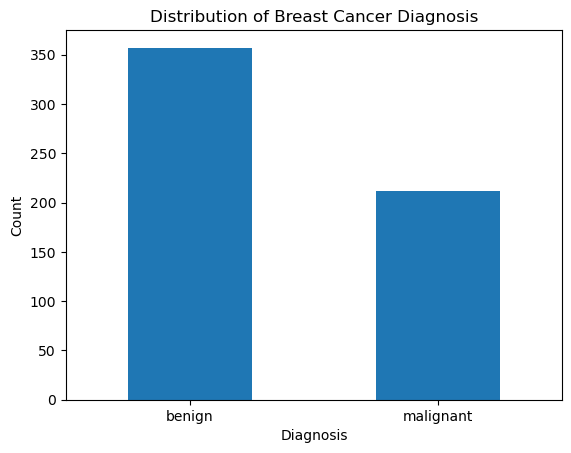

In [4]:
import matplotlib.pyplot as plt

df["diagnosis_label"].value_counts().plot(kind="bar")
plt.title("Distribution of Breast Cancer Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## 2. Feature Relationships and Correlation Analysis

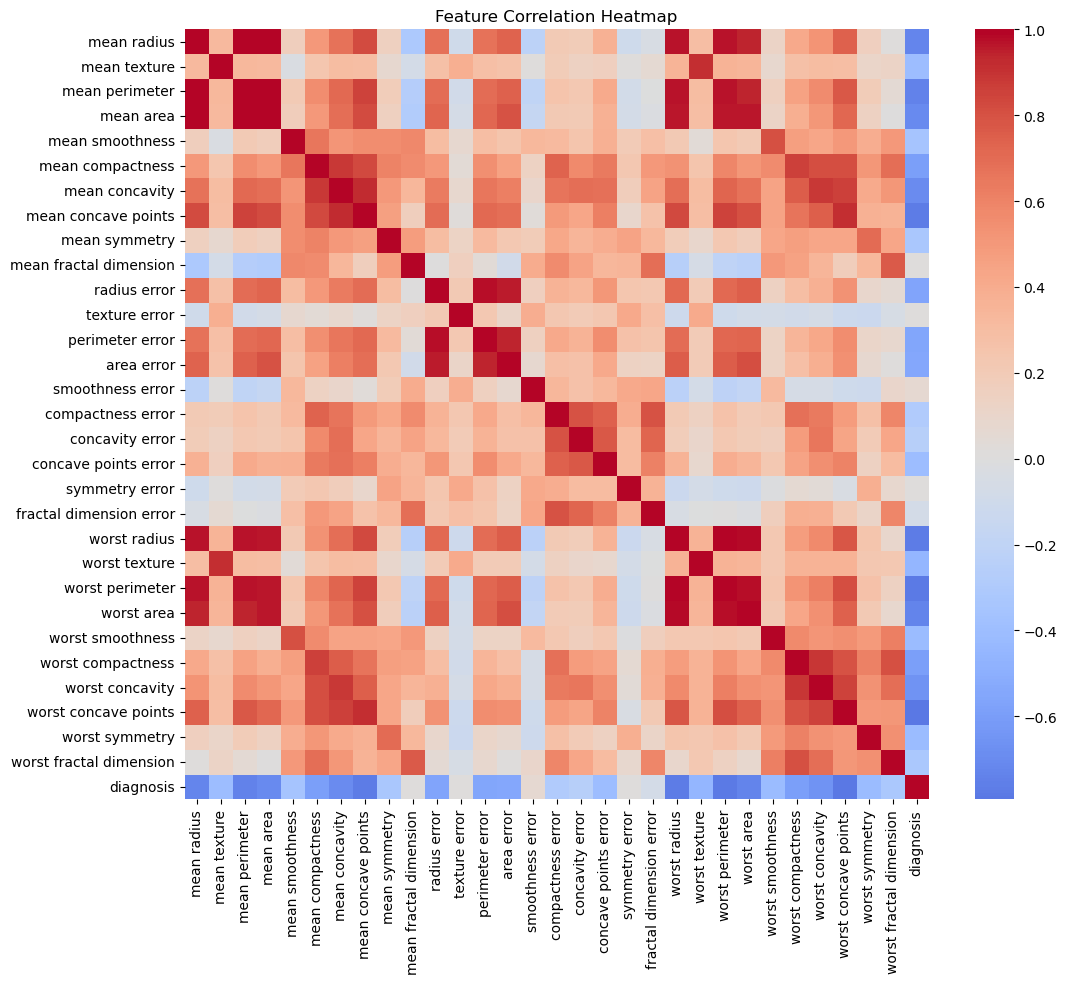

In [5]:
import seaborn as sns

# Correlation matrix
corr_matrix = df.drop(columns=["diagnosis_label"]).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

### Observations

- Several features are highly correlated, indicating redundancy.
- Strong correlations exist between radius, perimeter, and area.
- This suggests that some features may be capturing similar biological properties.

## 3. Model Training and Evaluation

In [6]:
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop(columns=["diagnosis", "diagnosis_label"])
y = df["diagnosis"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (455, 30)
Testing samples: (114, 30)


In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [8]:
y_pred = model.predict(X_test)

In [9]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.956140350877193

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### Model Performance

- The model achieves high accuracy in distinguishing between malignant and benign tumors.
- Precision and recall scores indicate strong performance for both classes.
- This suggests that the selected features are highly informative for classification.

In [10]:
import shap

In [11]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

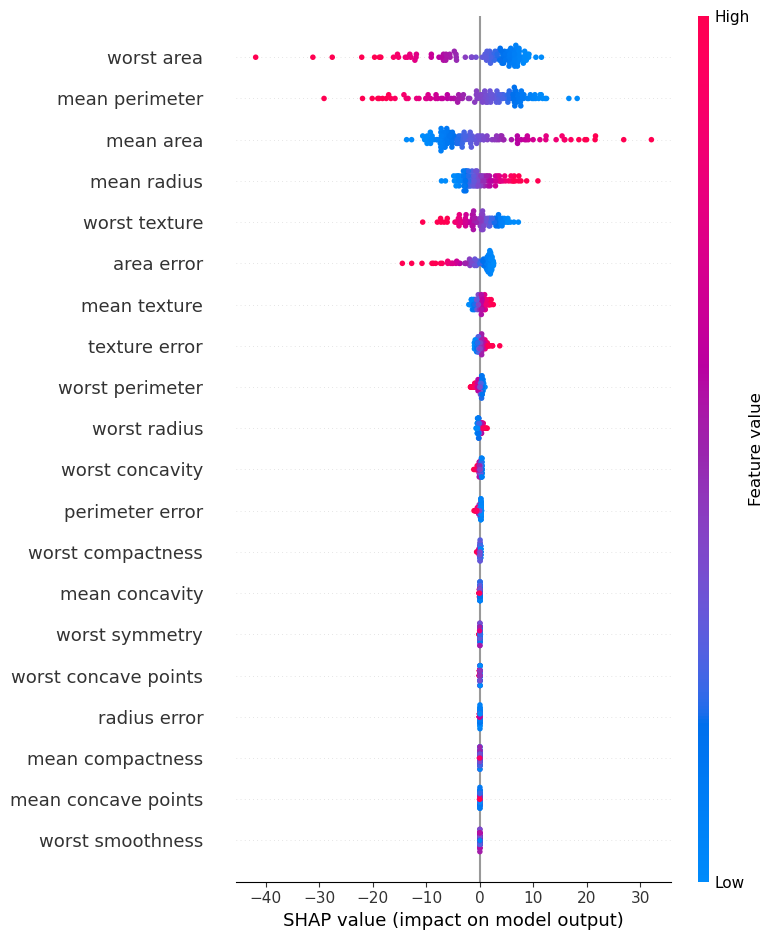

In [12]:
shap.summary_plot(shap_values, X_test)

## 4. Explainable AI and Feature Importance (SHAP)

### Key Insights

- The most influential features include worst area, mean perimeter, mean area, and mean radius.
- Higher values of these features tend to push predictions toward the malignant class.
- This suggests that tumor size and structural characteristics are critical factors in classification.
- These findings align with known clinical indicators used in breast cancer diagnosis.

### Interpretation

- The model is not only accurate but also biologically interpretable.
- It identifies meaningful patterns consistent with real-world medical knowledge.
- This strengthens confidence in the model’s predictions and highlights its potential relevance in clinical decision support.

# 5. Conclusion

This project demonstrates how machine learning can effectively classify breast cancer tumors using numerical diagnostic features.

The Logistic Regression model achieved approximately 96% accuracy while maintaining strong precision and recall across both classes.

Using SHAP explainability methods, the analysis identified biologically meaningful features such as tumor area, perimeter, and radius as major contributors to classification decisions.

The project highlights the importance of interpretable AI in healthcare, where understanding model behavior is critical for clinical trust and decision support.